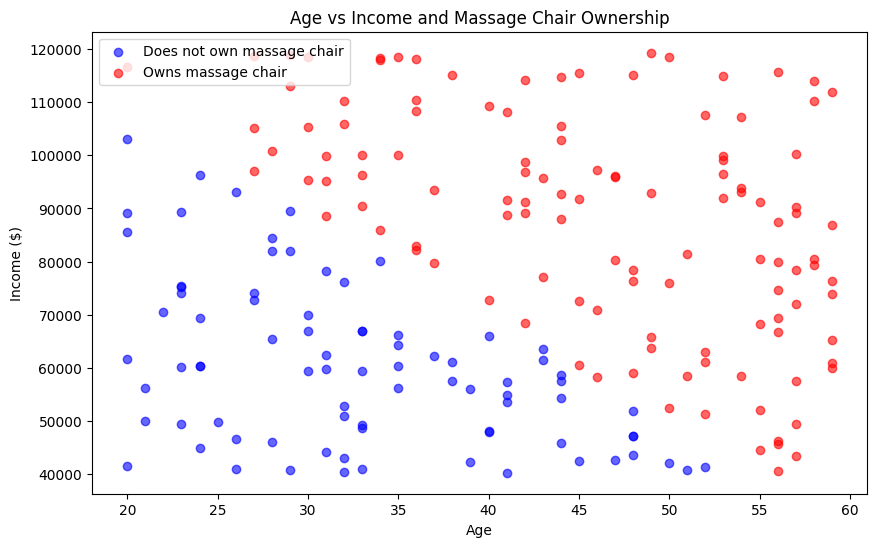

((200, 2), (200,))

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(2025)
age = np.random.randint(20, 60, size=200)
income = np.random.randint(40_000, 120_000, size=200) # typically lognormally distributed and correlated with age but simplified here
# Vertical split: young with high income or old with low income more likely to own massage chair, with linear boundary
owns_massage_chair = (income + (2000 * age) - 150_000) > 0

x_train = np.column_stack((age, income))
y_train = owns_massage_chair.astype(int)

# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(age[~owns_massage_chair], income[~owns_massage_chair], color='blue', label='Does not own massage chair', alpha=0.6)
plt.scatter(age[owns_massage_chair], income[owns_massage_chair], color='red', label='Owns massage chair', alpha=0.6)
plt.title('Age vs Income and Massage Chair Ownership')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend()
plt.show()

x_train.shape, y_train.shape


In [26]:
def knn_classify(x_train, y_train, x_query, k):
    y_query = []
    for x in x_query:
        # 1. Distance
        distance = np.linalg.norm(x_train - x, axis=1)

        # 2. Sort
        sorted_indices = np.argsort(distance)

        # 3. Select
        k_indices = sorted_indices[:k]

        # 4. Vote
        k_nearest_labels = y_train[k_indices]
        counts = np.bincount(k_nearest_labels)
        predicted_label = np.argmax(counts)

        y_query.append(predicted_label)
    return np.array(y_query)

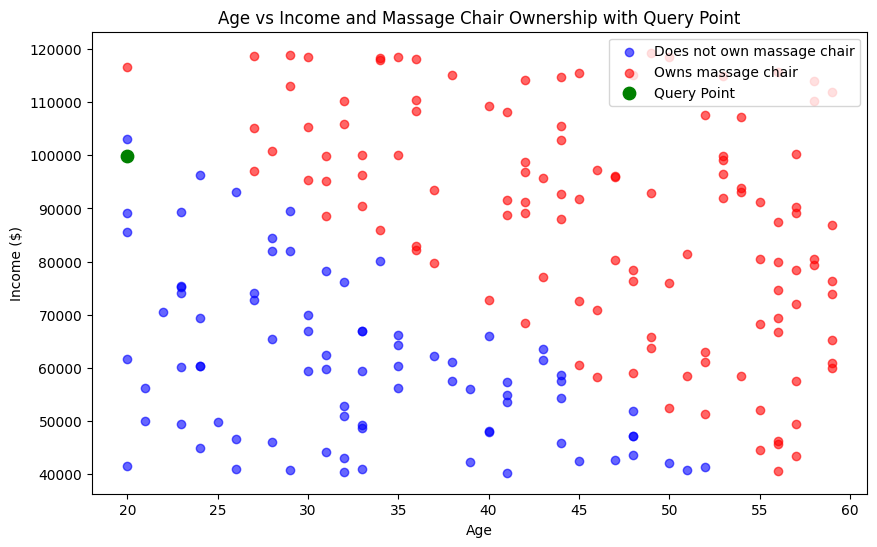

In [68]:
# Query point logically close to boundary but numerically far in income
x_query = np.array([[20, 99_900]])

# Plot with query point
plt.figure(figsize=(10, 6))
plt.scatter(age[~owns_massage_chair], income[~owns_massage_chair], color='blue', label='Does not own massage chair', alpha=0.6)
plt.scatter(age[owns_massage_chair], income[owns_massage_chair], color='red', label='Owns massage chair', alpha=0.6)
plt.scatter(x_query[0][0], x_query[0][1], color='green', label='Query Point', s=80)
plt.title('Age vs Income and Massage Chair Ownership with Query Point')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend(loc='upper right')
plt.show()

Predicted label for query point Age=20 Income=99,900: Owns Massage Chair


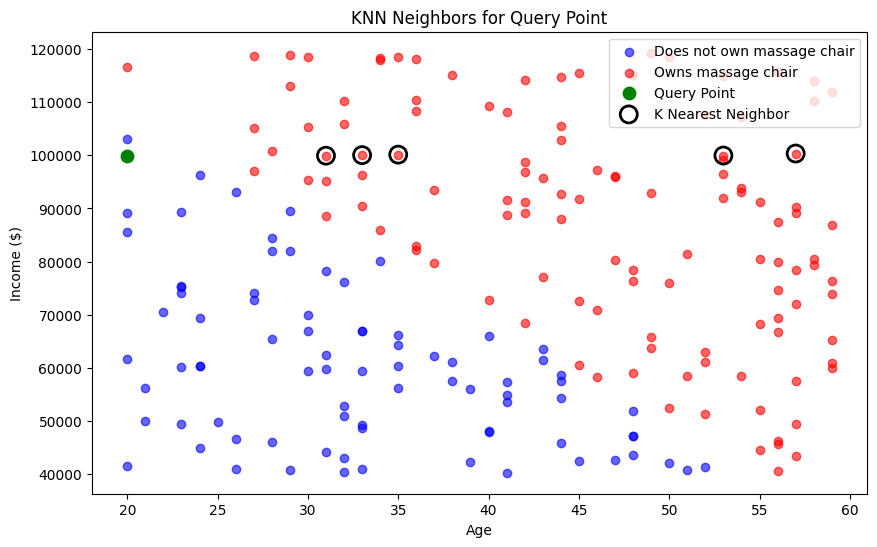

In [73]:
# Classify query point
k = 5
y_query = knn_classify(x_train, y_train, x_query, k)
print(f'Predicted label for query point Age={x_query[0][0]} Income={x_query[0][1]:,.0f}: {"Owns Massage Chair" if y_query[0] == 1 else "Does Not Own Massage Chair"}')

# Visualize neighbors
plt.figure(figsize=(10, 6))
plt.scatter(age[~owns_massage_chair], income[~owns_massage_chair], color='blue', label='Does not own massage chair', alpha=0.6)
plt.scatter(age[owns_massage_chair], income[owns_massage_chair], color='red', label='Owns massage chair', alpha=0.6)
plt.scatter(x_query[0][0], x_query[0][1], color='green', label='Query Point', s=80)
for i in range(k):
    idx = sorted_indices[i]
    plt.scatter(x_train[idx][0], x_train[idx][1], facecolors='none', edgecolors='black', s=150, linewidths=2, label=f'K Nearest Neighbor' if i == 0 else "")
plt.title('KNN Neighbors for Query Point')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend(loc='upper right')
plt.show()